# Théorie des jeux (En cours)

Ce notebook présente une manière de trouver les équilibres de Nash pour les jeux finis. D'après le Théorème de Nash, nous savons que de tels équilibres mixtes existent, l'objectif est donc de trouver ces stratégies numériquement.

L'objet python `GameMinizer` peut chercher les équilibres de Nash pour tout jeu à **n** joueurs avec un nombre d'actions pures fini pour chaque joueur.

Notre objet python cherche les équilibres de Nash en minimisant une **Fonction de regret F** construite de telle façon que ses minimums globaux, atteints lorsque **F=0**, soient les équilibres recherchés. La minimisation est effectuée grace à l'algorithme L-BFGS.

Finalement, nous avons analysé les limites de notre algorithme en présentants des jeux où l'algorithme ne converge que vers un minimum local ou point selle.



## Sommaire

### 1. Définition de l'objet
### 2. Convergence pour des jeux à 2 et 3 joueurs
### 3. Limites de l'algorithme

In [57]:
import torch
import numpy as np
from torch.optim import LBFGS
import matplotlib.pyplot as plt
import matplotlib as cm

torch.set_default_dtype(torch.float64)

## 1. Définition de l'objet

In [ ]:

class GameMinimizer:
    def __init__(self, num_players, num_actions, payoff_tensor,strategies_init=None):
        """
        :param num_players: int
        :param num_actions: list of int (nombre d'actions par joueur)
        :param payoff_tensor: torch.Tensor de dimension (num_players, action_p1, action_p2, ...)
        """
        self.num_players = num_players
        self.num_actions = num_actions
        self.payoff_tensor = payoff_tensor.to(torch.float64)
        
        # Initialisation des stratégies (paramètres optimisables)
        # On initialise avec une distribution uniforme + un peu de bruit
        self.strategies = []
        if strategies_init is None:
            for n in num_actions:
                s = torch.rand(n,dtype=torch.float64) # n uniformes
                s = s / s.sum() # chaque ligne deviens une distribution
                s=s[:-1]
                s.requires_grad_(True) # Permettra de calculer le gradient
                self.strategies.append(s) #tenseur avec toutes les stratégies
        else:
            self.strategies = [
                torch.tensor(s[:-1],dtype=torch.float64, requires_grad=True) 
                for s in strategies_init
            ]
        #Attention self.strategies ne contient uniquement les n-1 premières probabilités
        self.history = []
        self.loss_history = []
        self.gradient_norms_history = []
        self.final_stategies=[]

    def get_full_strategies(self):
            """ Reconstruit les vecteurs de probabilités complets (taille n) """
            full_strats = []
            for p in self.strategies:
                # La dernière probabilité est induite : 1 - somme des autres
                p_last = 1.0 - torch.sum(p)
                # On concatène pour avoir le vecteur complet [p1, p2, ..., pn]
                # torch.cat préserve le graphe de gradient
                s_full = torch.cat([p, p_last.unsqueeze(0)])
                full_strats.append(s_full)
            return full_strats

    def compute_utility(self, strategies_list, player_idx):
        """
        Calcule l'espérance du gain u(i) pour le joueur i.
        u(i) = sum_{a} [ P(a) * Payoff_i(a) ]
        """
        # On crée le produit extérieur des probabilités pour obtenir la probabilité de chaque profil d'action
        # On calcul la probabilité de chaque cas (produit de toutes les probabilités de l'action de chaque joueur car indépendance) puis multiplication avec le payoff/gain actions pures
        prob_matrix = strategies_list[0]
        for i in range(1, self.num_players):
            prob_matrix = torch.matmul(prob_matrix.unsqueeze(-1), strategies_list[i].unsqueeze(0)) #multiplication(matmul) entre une vecteur colonne (unsqueeze(-1)) et ligne (unsqueeze(0)) => effectue le produit exterieur => matrice des probabilités d'intersection
            prob_matrix = prob_matrix.view(-1) # On aplatit pour continuer le produit extérieur si > 2 joueurs (grosse matrice qu'on applatie après)
        
        # Reshape pour correspondre au tenseur de gains
        prob_matrix = prob_matrix.view(self.payoff_tensor.shape[1:]) # 1: car payooff_tensor a sa premiàre dimension qui correspond au joueur pour qui les gains vont etre, donc on enlève la dimension nombre de joueurs payoff_tensor ne change pas de taille selon le joueur
        #1ere dimension joueur 0 2eme dimension joueur 1 .... 
        
        # Gain espéré : somme pondérée des gains par les probabilités
        return torch.sum(prob_matrix * self.payoff_tensor[player_idx])

    def compute_loss(self):
        """ Calcule la fonction F : somme des regrets + pénalité de distribution """
        probs = self.get_full_strategies()
        total_regret = 0
        penalty = 0
        
        for i in range(self.num_players):
            # 1. Calcul de l'utilité actuelle u(i)(x_i, x_others) v   => le gain du joueur i selon ses décisions actuelles
            u_current = self.compute_utility(probs, i)
            
            # 2. Calcul des regrets par rapport aux actions pures k
            for k in range(self.num_actions[i]):
                # Stratégie où le joueur i joue l'action pure k  P(joueur joue k) = 1, 0 sinon
                pure_strategy_i = torch.zeros(self.num_actions[i],dtype=torch.float64)
                pure_strategy_i[k] = 1.0
                
                probs_with_pure = [p for p in probs] 
                probs_with_pure[i] = pure_strategy_i # On modifie juste la stratégie du joueur i
                
                u_pure = self.compute_utility(probs_with_pure, i) # utilité avec stratégie pure
                
                # g_i = u_current - u_pure
                # On veut minimiser le regret de ne pas avoir joué k : max(0, u_pure - u_current)^2
                regret_k = torch.clamp(u_pure - u_current, min=0)**2
                total_regret += regret_k
            
            # 3. Pénalité pour non-respect de la loi de probabilité
            #La somme fait 1
            sum_prob = torch.sum(self.strategies[i])
            penalty += 1e3 * torch.relu(sum_prob - 1)**2
            # et les valeurs sont positives
            penalty += 1e3 * torch.sum(torch.relu(-probs[i])**2)

        return total_regret + penalty

    def solve(self, iterations=50):
        optimizer = LBFGS(self.strategies, lr=0.5, max_iter=1, history_size=10,tolerance_change= 1e-15,tolerance_grad=1e-15)

        def closure():
            optimizer.zero_grad()
            loss = self.compute_loss()
            loss.backward()

            with torch.no_grad():
                grads = [p.grad.flatten() for p in self.strategies if p.grad is not None]
                norm_grads=torch.norm(torch.cat(grads)).item()
                self.gradient_norms_history.append(norm_grads)
                    

            return loss

        for i in range(iterations):
            with torch.no_grad():
                current_probs = [p.detach().clone() for p in self.get_full_strategies()] # detach permet de redevenir un simple tableau sans tracker des opérations pour le gradient 
                self.history.append(current_probs)
            loss = optimizer.step(closure)
            self.loss_history.append(loss.item())
            if i % 10 == 0:
                print(f"Itération {i}, Loss: {loss.item():.6f}")

        self.final_stategies=[np.round(s.detach().numpy(),4) for s in self.get_full_strategies()] # detacher du gradient les distributions
        return self.final_stategies
    
    def plot_evolution(self):
        hist = np.array([[p.numpy() for p in step] for step in self.history])
        iterations = range(len(hist))
        
        # On crée une figure avec 2 sous-graphiques (subplots)
        fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(12, 15))

        # --- Graphique 1 : Probabilités ---
        for i in range(self.num_players):
            for j in range(self.num_actions[i]):
                ax1.plot(iterations, hist[:, i, j], 
                        label=f"Joueur {i+1} - Action {j+1}")
        
        ax1.set_title("Évolution des probabilités de stratégie")
        ax1.set_ylabel("Probabilité")
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)

        # --- Graphique 2 : Fonction de Perte (Convergence) ---
        ax2.plot(range(len(self.loss_history)), self.loss_history, color='red', lw=2)
        ax2.set_yscale('log') # Échelle logarithmique souvent mieux pour voir la convergence fine
        ax2.set_title("Convergence de la fonction de perte (Log scale)")
        ax2.set_xlabel("Itérations (Pas BFGS)")
        ax2.set_ylabel("Loss (Regret + Pénalités)")
        ax2.grid(True, alpha=0.3)

        # --- Graphique 2 : Fonction de Perte (Convergence) ---
        ax3.plot(range(len(self.gradient_norms_history)), self.gradient_norms_history, color='red', lw=2)
        ax3.set_yscale('log') # Échelle logarithmique souvent mieux pour voir la convergence fine
        ax3.set_title("Évolution de la norme du gradient")
        ax3.set_xlabel("Itérations (Pas BFGS)")
        ax3.set_ylabel("Norme L2 du gradient (Log scale)")
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        print("\nDistributions finales :")
        for i, strat in enumerate(self.final_stategies):
            print(f"Joueur {i}: {strat}")   


## 2. Convergence pour des jeux à 2 et 3 joueurs

## Jeu Pierre Feuille Papier Ciseaux

Itération 0, Loss: 0.108675
Itération 10, Loss: 0.000002
Itération 20, Loss: 0.000000
Itération 30, Loss: 0.000000
Itération 40, Loss: 0.000000


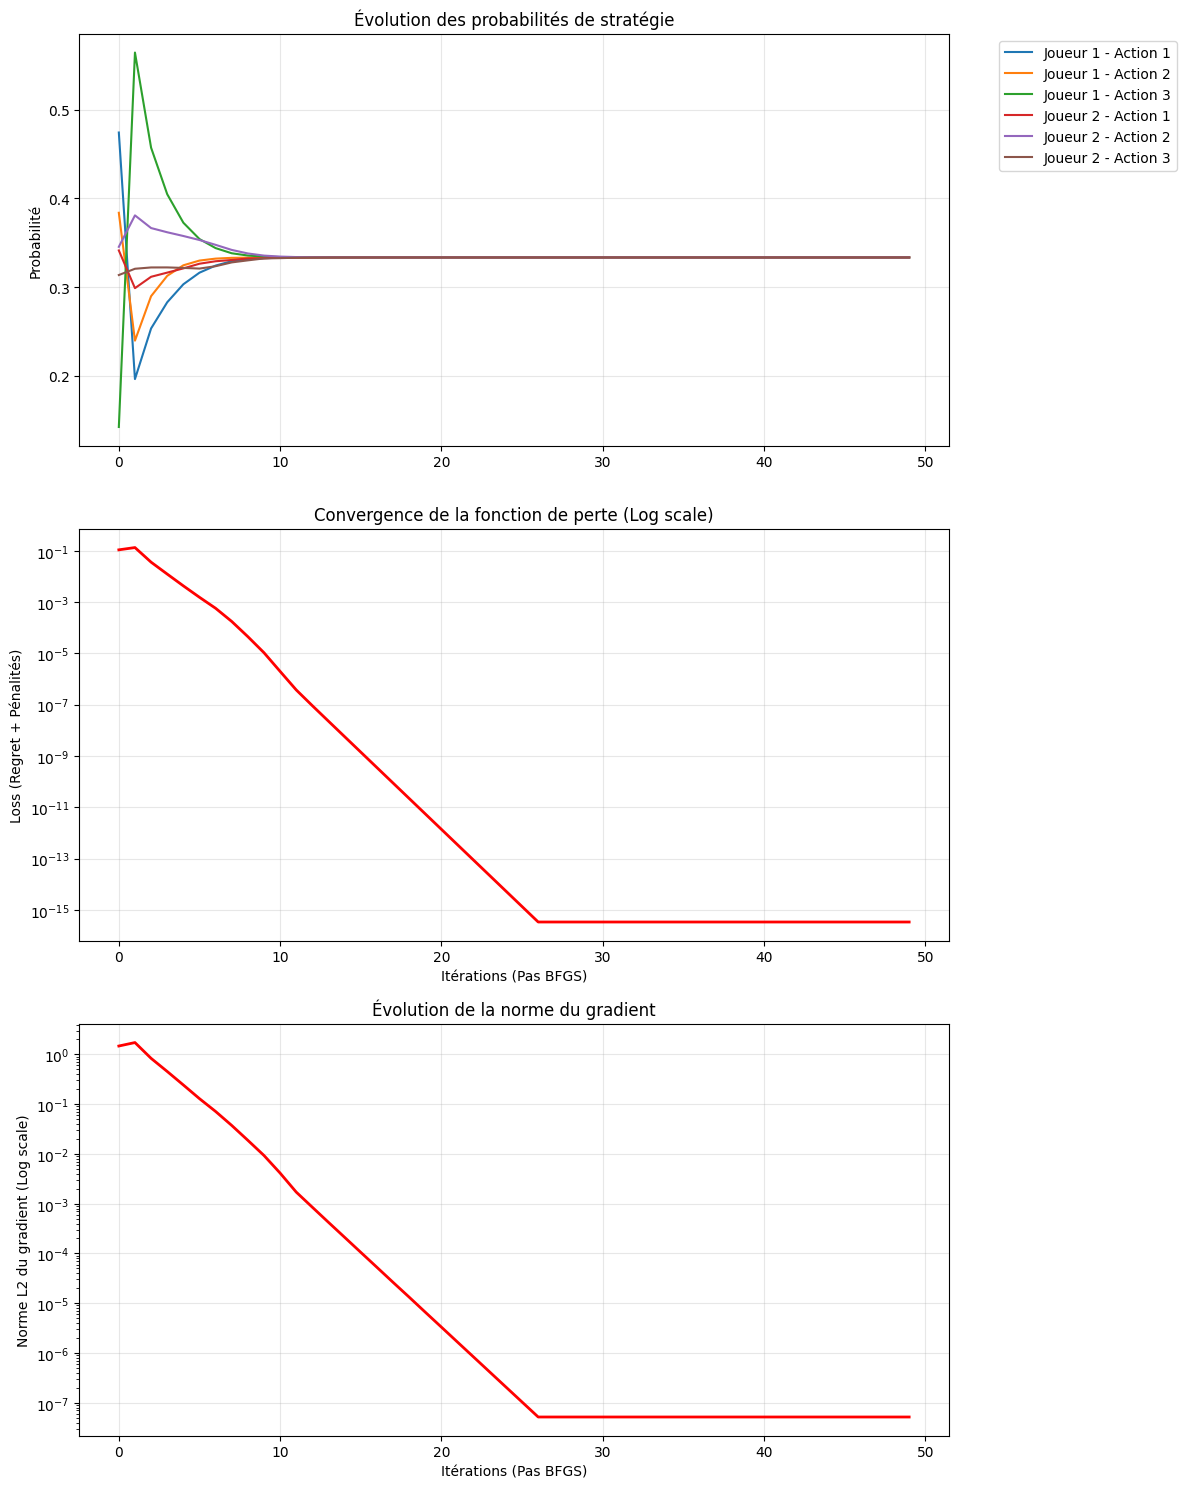


Distributions finales :
Joueur 0: [0.3333 0.3333 0.3333]
Joueur 1: [0.3333 0.3333 0.3333]


In [59]:
# Configuration du jeu : Pierre-Papier-Ciseaux
# Gains pour Joueur 0 (Matrice de gain)
# P1 \ P2 | Pierre | Papier | Ciseaux
# Pierre   |    0   |   -1   |    1
# Papier   |    1   |    0   |   -1
# Ciseaux  |   -1   |    1   |    0

payoffs_p0 = torch.tensor([
    [0., -1., 1.],
    [1., 0., -1.],
    [-1., 1., 0.]
])
payoffs_p1 = -payoffs_p0  # Somme nulle

# Tenseur global (2 joueurs, actions [3, 3])
game_tensor = torch.stack([payoffs_p0, payoffs_p1])

# Initialisation et résolution
game = GameMinimizer(num_players=2, num_actions=[3, 3], payoff_tensor=game_tensor)
final_strategies = game.solve()
game.plot_evolution()


Itération 0, Loss: 0.000200
Itération 10, Loss: 0.000000
Itération 20, Loss: 0.000000
Itération 30, Loss: 0.000000
Itération 40, Loss: 0.000000


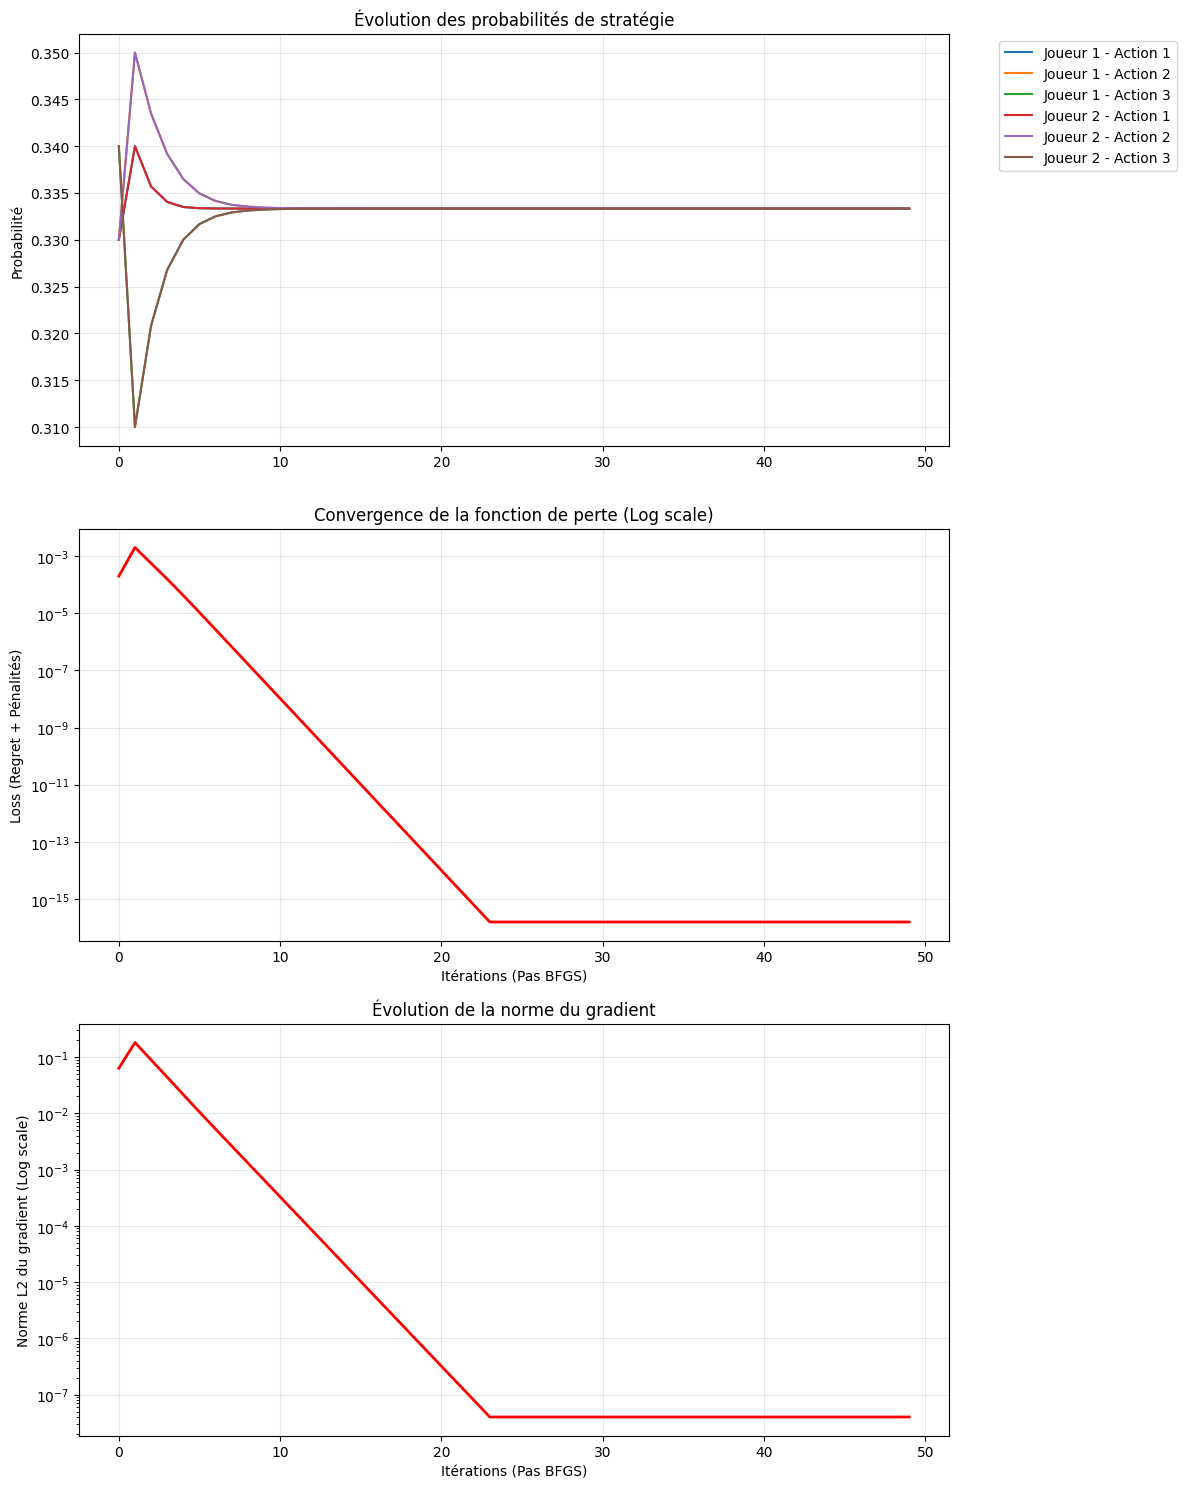


Distributions finales :
Joueur 0: [0.3333 0.3333 0.3333]
Joueur 1: [0.3333 0.3333 0.3333]


In [60]:

payoff_j0 = torch.tensor([[ 0., -2.,  1.],
                          [ 1.,  0., -3.],
                          [-1.,  4.,  0.]], dtype=torch.float64)
payoff_j1 = torch.tensor([[ 0.,  1., -1.],
                          [-1.,  0.,  1.],
                          [ 1., -1.,  0.]], dtype=torch.float64)

strategies_init = [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34]]
# Tenseur global (2 joueurs, actions [3, 3])
game_tensor = torch.stack([payoffs_p0, payoffs_p1])

# Initialisation et résolution
game2 = GameMinimizer(num_players=2, num_actions=[3, 3], payoff_tensor=game_tensor
, strategies_init=strategies_init)
final_strategies = game2.solve()
game2.plot_evolution()

## Gardien et tireur

Itération 0, Loss: 1.000000
Itération 10, Loss: 0.000064
Itération 20, Loss: 0.000000
Itération 30, Loss: 0.000000
Itération 40, Loss: 0.000000


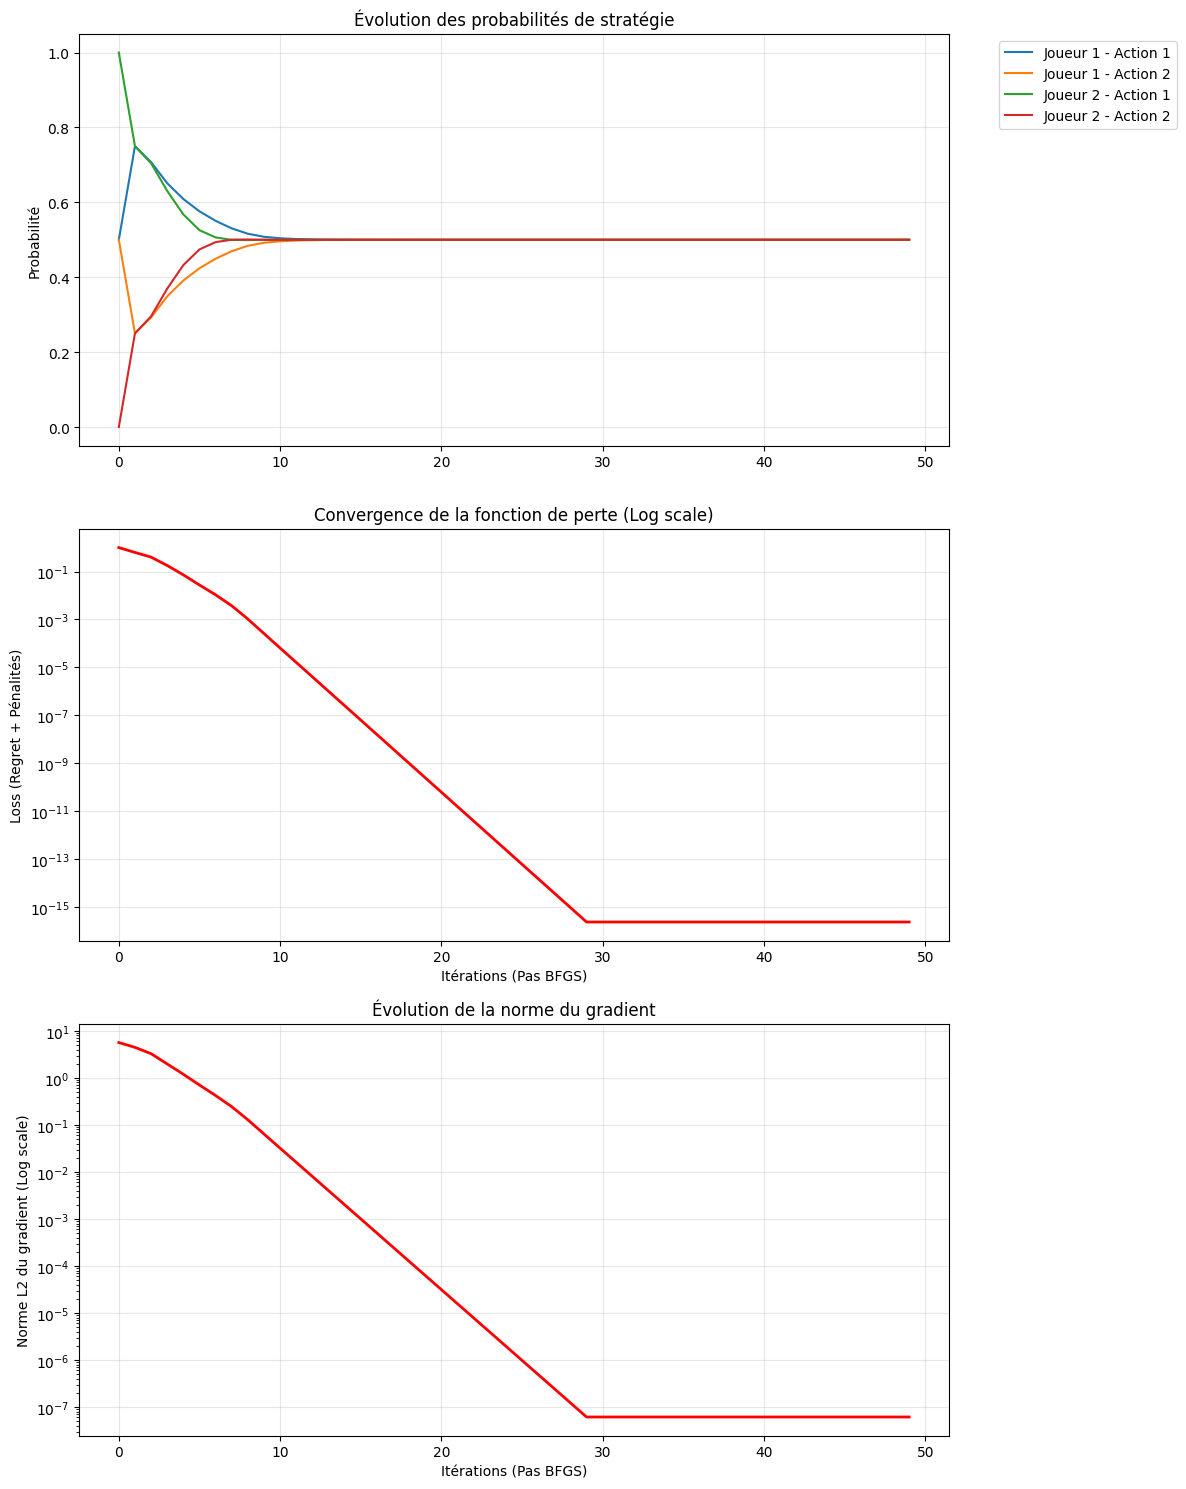


Distributions finales :
Joueur 0: [0.5 0.5]
Joueur 1: [0.5 0.5]


In [61]:
# Matrice de gain pour le Gardien (P0)
# Colonnes = Gardien (G, D) | Lignes = Tireur (G, D)
payoffs_p0 = torch.tensor([
    [ 1, -1],  # Tireur tire à Gauche
    [-1,  1]   # Tireur tire à Droite
], dtype=torch.float64)

payoffs_p1 = -payoffs_p0  # Somme nulle

# Tenseur global [2 joueurs, 2 actions, 2 actions]
game_tensor_penalty = torch.stack([payoffs_p0, payoffs_p1])

strategies_initiales = [[0.5,0.5],[1,0]]
# Création de l'instance pour le Penalty
penalty_game = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=game_tensor_penalty,
    strategies_init = strategies_initiales
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = penalty_game.solve()

penalty_game.plot_evolution()


## Jeu de coopération

Itération 0, Loss: 0.028800
Itération 10, Loss: 0.000000


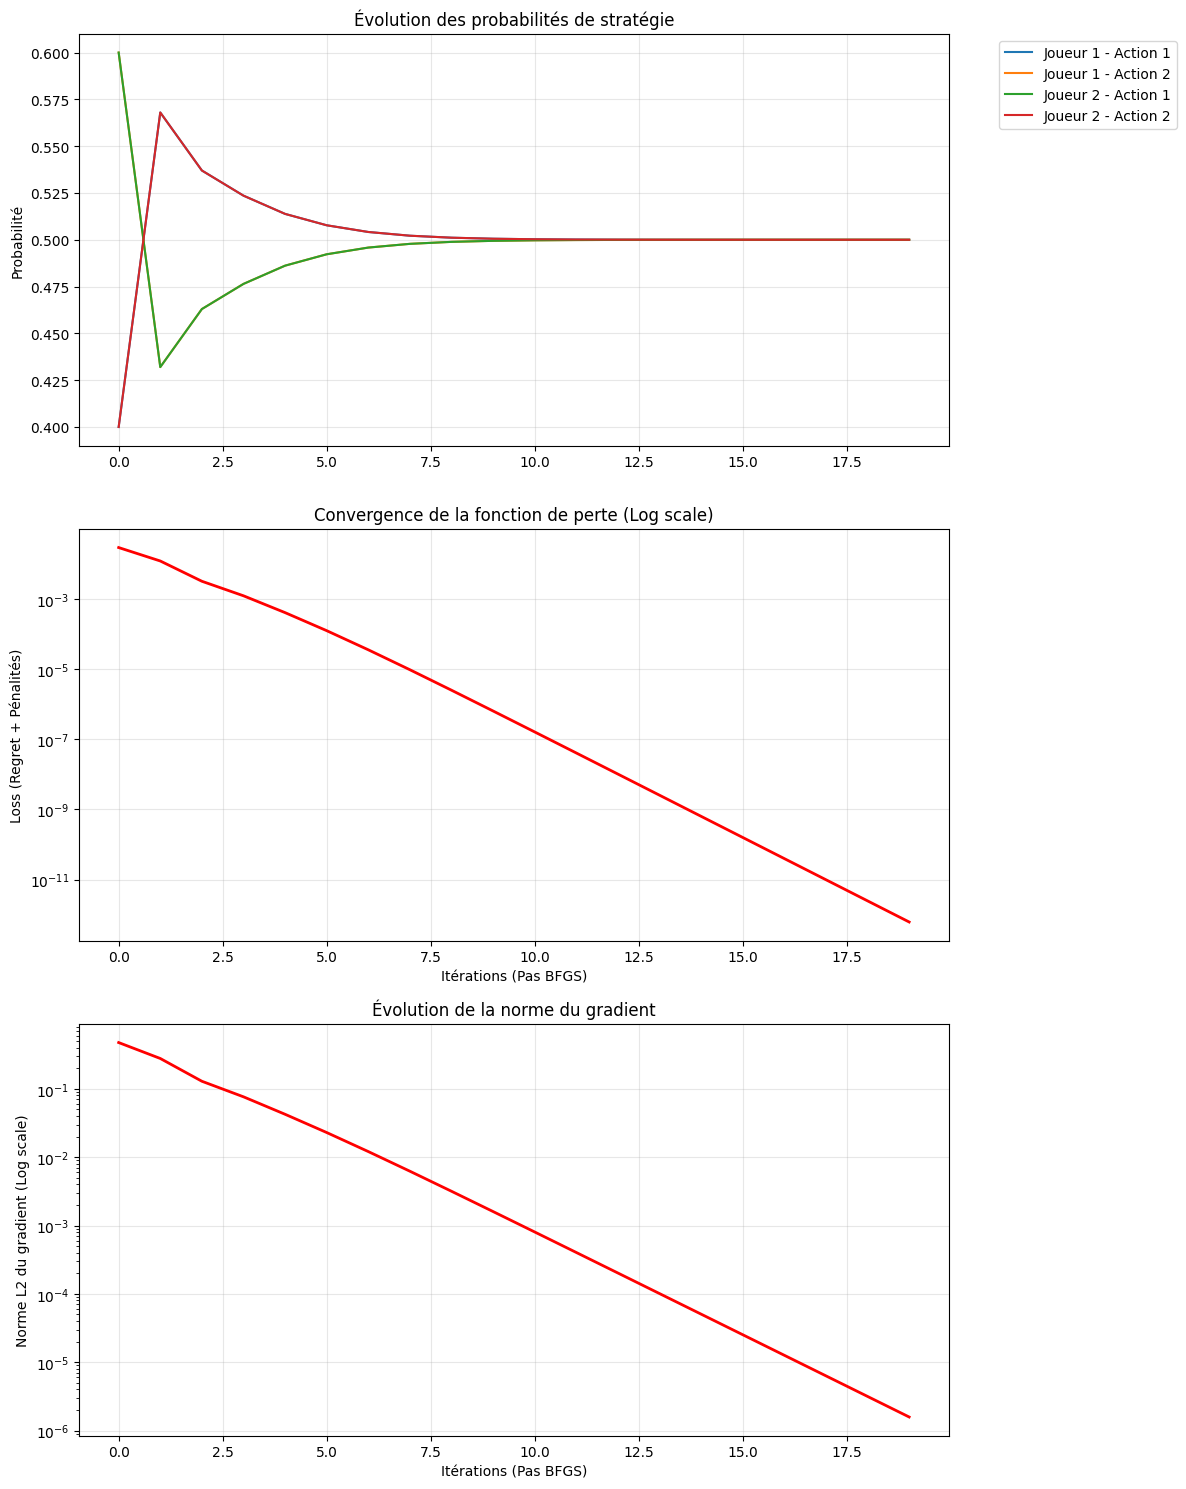


Distributions finales :
Joueur 0: [0.5 0.5]
Joueur 1: [0.5 0.5]


In [62]:
# Matrice de gain pour le Gardien (P0)
# Colonnes = Gardien (G, D) | Lignes = Tireur (G, D)
payoffs_p0 = torch.tensor([
    [ 1.0, 0.0],  # Tireur tire à Gauche
    [0.0,  1.0]   # Tireur tire à Droite
], dtype=torch.float64)

payoffs_p1 = payoffs_p0 

# Tenseur global [2 joueurs, 2 actions, 2 actions]
game_tenseur_cooperation = torch.stack([payoffs_p0, payoffs_p1])

strategies_initales = [[0.4,0.6],[0.6,0.4]]
# Création de l'instance pour le Penalty
game_cooperation = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=game_tenseur_cooperation,
    strategies_init=strategies_initales
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = game_cooperation.solve(iterations=20)

game_cooperation.plot_evolution()



Itération 0, Loss: 0.680000
Itération 10, Loss: 0.084375
Itération 20, Loss: 0.000000
Itération 30, Loss: 0.000000
Itération 40, Loss: 0.000000
Itération 50, Loss: 0.000000
Itération 60, Loss: 0.000000
Itération 70, Loss: 0.000000
Itération 80, Loss: 0.000000
Itération 90, Loss: 0.000000


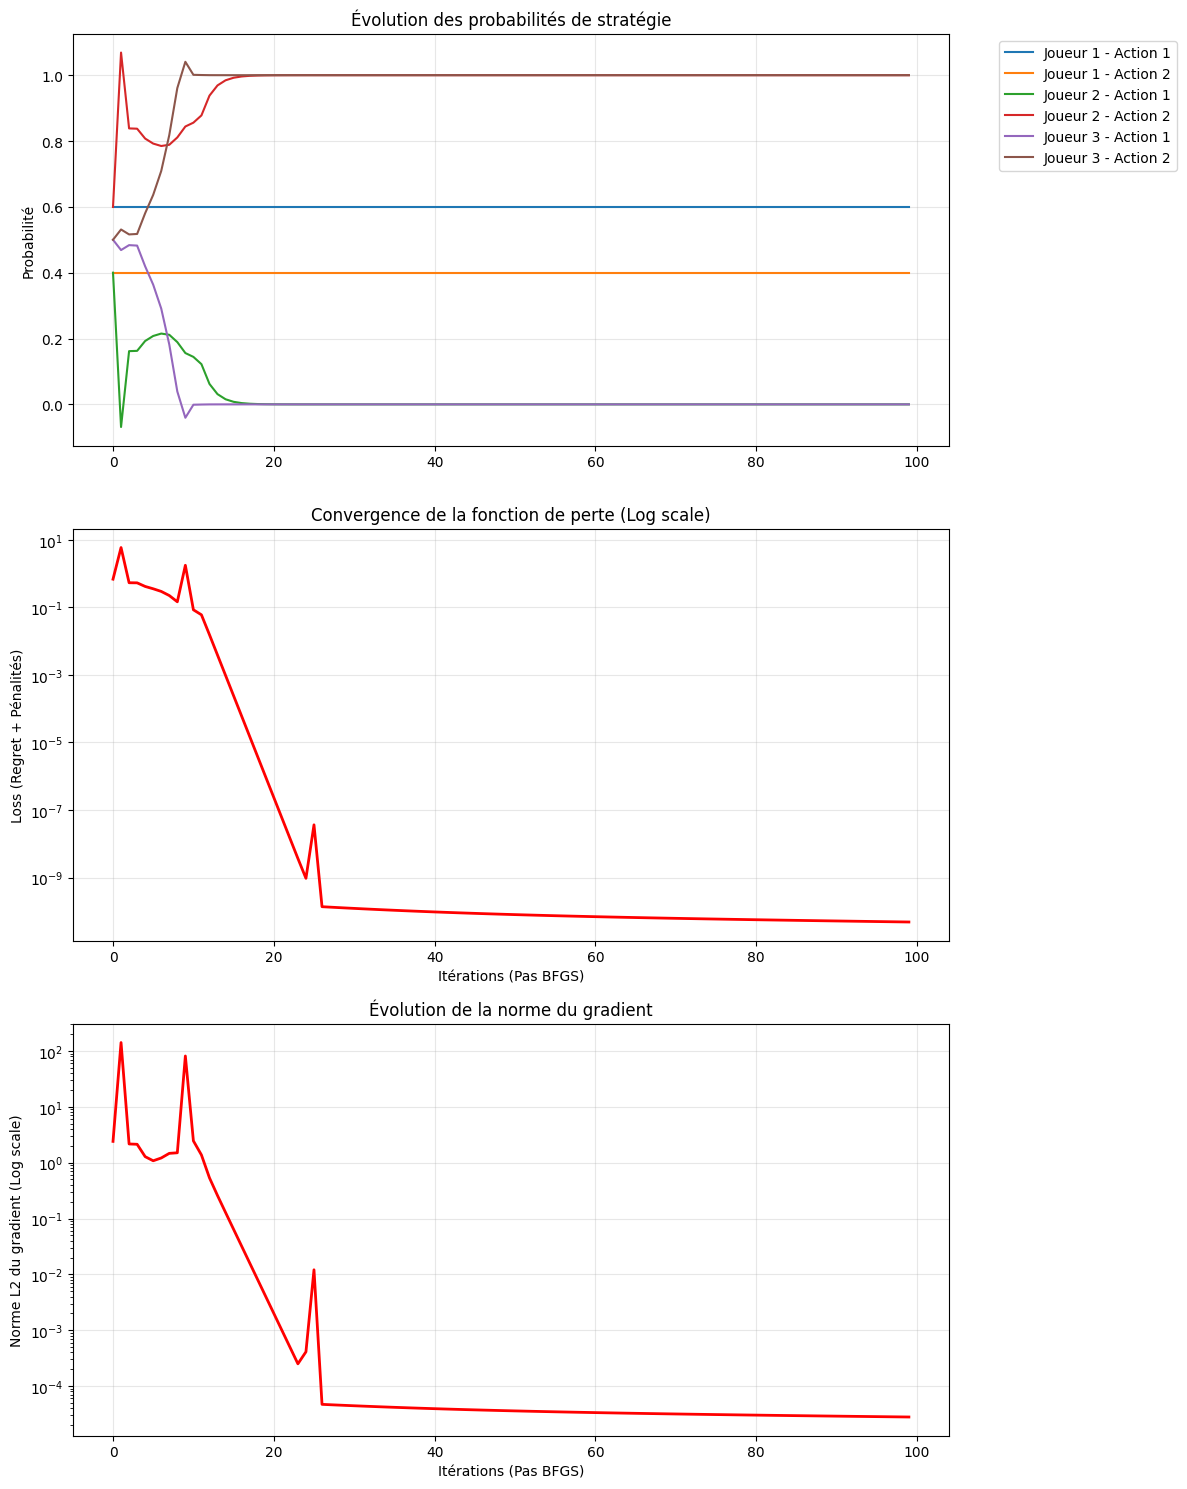


Distributions finales :
Joueur 0: [0.6 0.4]
Joueur 1: [0. 1.]
Joueur 2: [0. 1.]


In [63]:
# 1. On définit les gains pour chaque joueur sous forme de matrices 2x2
# Pour 3 joueurs, on a besoin de "tranches" (slices) : 
# Gain quand J2 choisit Action 0 (G) vs Gain quand J2 choisit Action 1 (D)

# --- Joueur 0 ---
p0_si_J2_G = torch.tensor([[1, -1], [1, -1]], dtype=torch.float64) # J2 joue G
p0_si_J2_D = torch.tensor([[-1, 1], [-1, 1]], dtype=torch.float64) # J2 joue D
payoff_p0 = torch.stack([p0_si_J2_G, p0_si_J2_D], dim=2) # On empile sur la 3ème dimension

# --- Joueur 1 --- (Même logique de coopération)
p1_si_J2_G = torch.tensor([[-1, 1], [-1, 1]], dtype=torch.float64)
p1_si_J2_D = torch.tensor([[-1, 1], [-1, 1]], dtype=torch.float64)
payoff_p1 = torch.stack([p1_si_J2_G, p1_si_J2_D], dim=2)

# --- Joueur 2 ---
p2_si_J2_G = -torch.tensor([[-1, 1], [-1, 1]], dtype=torch.float64)
p2_si_J2_D = torch.tensor([[-1, 1], [-1, 1]], dtype=torch.float64)
payoff_p2 = torch.stack([p2_si_J2_G, p2_si_J2_D], dim=2)

# 2. Tenseur global [Nb_joueurs, Act_J0, Act_J1, Act_J2] -> Taille [3, 2, 2, 2]
game_tensor_3p = torch.stack([payoff_p0, payoff_p1, payoff_p2])

# 3. Initialisation (3 joueurs, 2 actions chacun)
# On donne les probas complètes, le __init__ s'occupera de garder n-1
strategies_initiales_3p = [[0.6, 0.4], [0.4, 0.6], [0.5, 0.5]]

game_3p = GameMinimizer(
    num_players=3, 
    num_actions=[2, 2, 2], 
    payoff_tensor=game_tensor_3p,
    strategies_init=strategies_initiales_3p
)

# 4. Résolution
final_strats = game_3p.solve(iterations=100)

# 5. Affichage
game_3p.plot_evolution()


## 3. Limites de l'algorithme

In [64]:
def compute_loss_2x2(p, q, payoffs):
    """
    Calcule la perte (regret total**2) pour les probabilités p et q.
    p : probabilité que J1 joue l'action 0
    q : probabilité que J2 joue l'action 0
    """
    p=torch.tensor(p)
    q=torch.tensor(q)
    # Stratégies complètes
    strat_j1 = torch.stack([p, 1-p])
    strat_j2 = torch.stack([q, 1-q])
    
    # --- Utilités actuelles ---
    # Produit extérieur des probas (forme 2x2)
    probas_jointes = torch.ger(strat_j1, strat_j2)
    
    # Utilité = Somme(probas * gains)
    u1 = torch.sum(probas_jointes * payoffs[0])
    u2 = torch.sum(probas_jointes * payoffs[1])
    
    # --- Utilités pures ---
    # Gains si J1 joue l'action pure 0 ou 1, sachant strat_j2
    u1_pures = torch.matmul(payoffs[0], strat_j2) 
    # Gains si J2 joue l'action pure 0 ou 1, sachant strat_j1
    u2_pures = torch.matmul(strat_j1, payoffs[1])

    # --- Regrets ---
    regret1 = torch.sum(torch.clamp(u1_pures - u1, min=0)**2)
    regret2 = torch.sum(torch.clamp(u2_pures - u2, min=0)**2)

    penalty=0
    penalty += 1e3 * torch.relu(p - 1)**2
    penalty += 1e3 * torch.relu(q - 1)**2
    penalty += 1e3 * torch.sum(torch.relu(-p)**2)
    penalty += 1e3 * torch.sum(torch.relu(-q)**2)

    return regret1 + regret2 + penalty


def plot_regret(payoff_j1, payoff_j2, plateau = None):

    # Tenseur global [Nb_joueurs, Act_J1, Act_J2]
    payoff_tensor = torch.stack([payoff_j1, payoff_j2])

    n_points = 50
    p_coords = torch.linspace(-0.05, 1.05, n_points)
    q_coords = torch.linspace(-0.05, 1.05, n_points)

    # Création de la grille 2D
    P, Q = torch.meshgrid(p_coords, q_coords, indexing='ij')

    # Initialisation de la matrice des pertes
    Z = torch.zeros_like(P)

    # Calcule la perte pour chaque point (p, q) de la grille
    # Note: On utilise des boucles ici juste pour le calcul de la grille d'affichage
    for i in range(n_points):
        for j in range(n_points):
            Z[i, j] = compute_loss_2x2(P[i, j], Q[i, j], payoff_tensor)
            if plateau is not None:
                Z[i,j] = min(Z[i,j],plateau)

    # Conversion en numpy pour matplotlib
    P_np = P.numpy()
    Q_np = Q.numpy()
    Z_np = Z.numpy()

    # ==========================================
    # 4. Affichage Graphique
    # ==========================================
    fig = plt.figure(figsize=(14, 6))

    # --- Vue 3D ---
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    # Remplace 5.0 par la valeur max que tu veux afficher
    surf = ax1.plot_surface(P_np, Q_np, Z_np, cmap='viridis',
                        linewidth=0, antialiased=False, alpha=0.8)
    ax1.set_xlabel('Probabilité J1 (p)')
    ax1.set_ylabel('Probabilité J2 (q)')
    ax1.set_zlabel('Fonction de Perte (f)')
    ax1.set_title('Surface de la fonction de Regret')
    #ax1.view_init(elev=30, azim=20)

    # ---------------------------
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)


    # --- Vue 2D (Contour Plot) ---
    ax2 = fig.add_subplot(1, 2, 2)
    contour = ax2.contourf(P_np, Q_np, Z_np, levels=20, cmap='viridis')
    ax2.set_xlabel('Probabilité J1 (p)')
    ax2.set_ylabel('Probabilité J2 (q)')
    ax2.set_title('Courbes de niveau de la perte (Nash à f=0)')
    # On crée un masque : True là où la perte est minuscule
    nash_mask = Z_np < 1e-2

    # On utilise scatter pour afficher TOUS les points de la grille qui sont des Nash
    # On ne met pas de label ici pour éviter de surcharger la légende si on a 100 points
    ax2.scatter(P_np[nash_mask], Q_np[nash_mask], color='red', s=10, label='Zones Nash (f≈0)')

    ax2.legend()
    fig.colorbar(contour, ax=ax2)
    plt
    plt.tight_layout()
    plt.show()



C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p=torch.tensor(p)
C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q=torch.tensor(q)


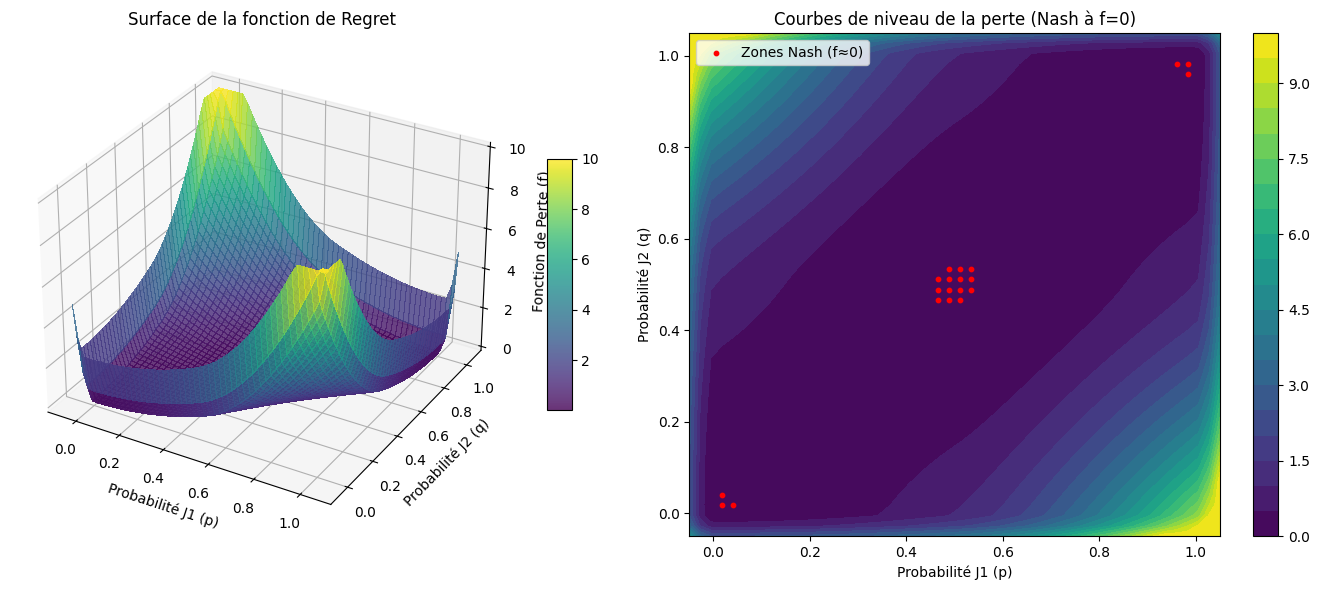

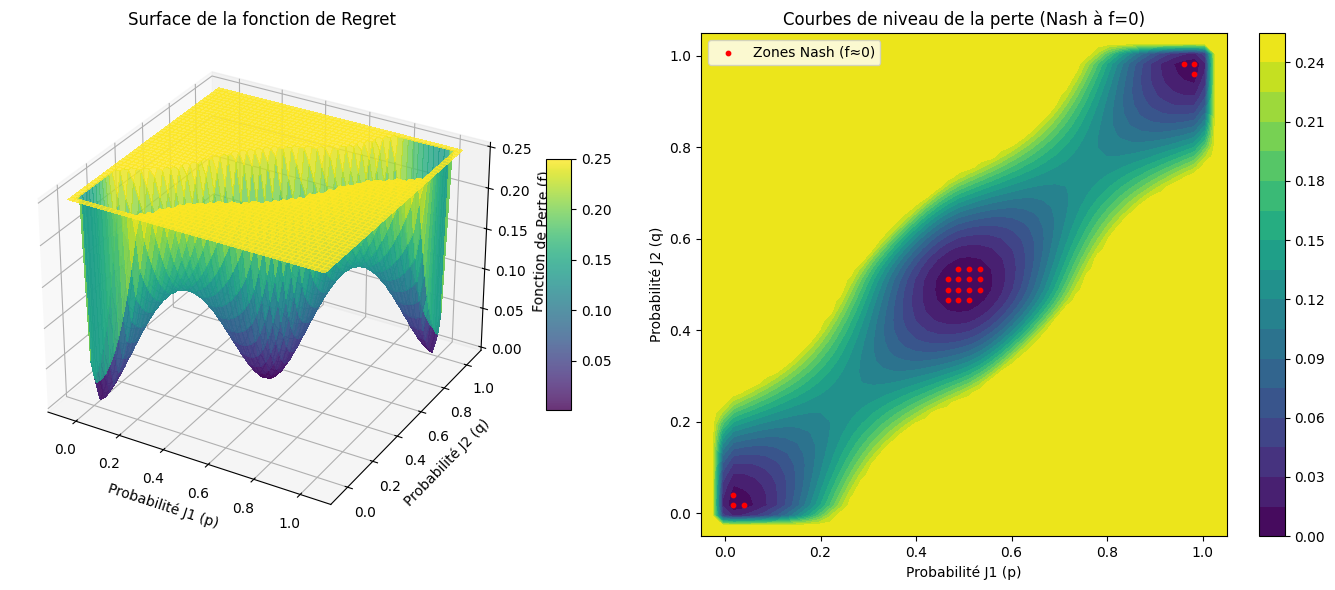

In [65]:
payoff_j1 = torch.tensor([[1,-1], 
                          [-1,1]], dtype=torch.float64)
# Jeu symétrique pour J2
payoff_j2 = torch.tensor([[1,-1], 
                          [-1,1]], dtype=torch.float64)

payoff_tensor = torch.stack([payoff_j1, payoff_j2])

plot_regret(payoff_j1,payoff_j2,plateau=10)
plot_regret(payoff_j1,payoff_j2,plateau=0.25)


C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p=torch.tensor(p)
C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q=torch.tensor(q)


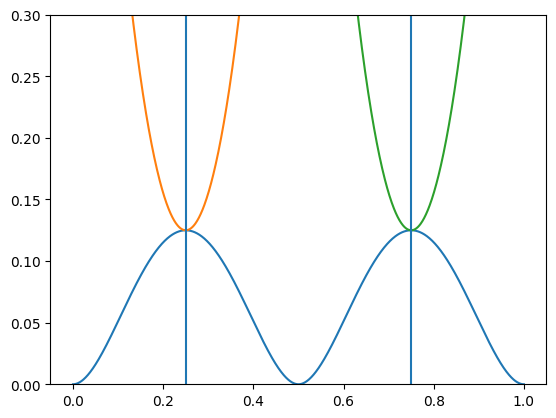

In [66]:
X= torch.linspace(0, 1, 1000)
Y= torch.zeros_like(X)
Y2= torch.zeros_like(X)
Y3= torch.zeros_like(X)

for i,x in enumerate(X):
    Y[i] = compute_loss_2x2(X[i],X[i],payoff_tensor)
    Y2[i] = compute_loss_2x2(X[i],0.5-X[i],payoff_tensor)
    Y3[i] = compute_loss_2x2(X[i],1.5-X[i],payoff_tensor)


plt.plot(X,Y)
plt.plot(X,Y2)
plt.plot(X,Y3)
plt.axvline(x=0.25)
plt.axvline(x=0.75)
plt.ylim(0, 0.3)
plt.show()
# => point selle en (0.25,0.25) et (0,75,0,75)


Les points (0.25,0.25) et (0,75,0.75) sont des points-selles

Itération 0, Loss: 0.250000
Itération 10, Loss: 0.031250
Itération 20, Loss: 0.031250
Itération 30, Loss: 0.031250
Itération 40, Loss: 0.031250
Itération 50, Loss: 0.031250
Itération 60, Loss: 0.031250
Itération 70, Loss: 0.031250
Itération 80, Loss: 0.031250
Itération 90, Loss: 0.031250


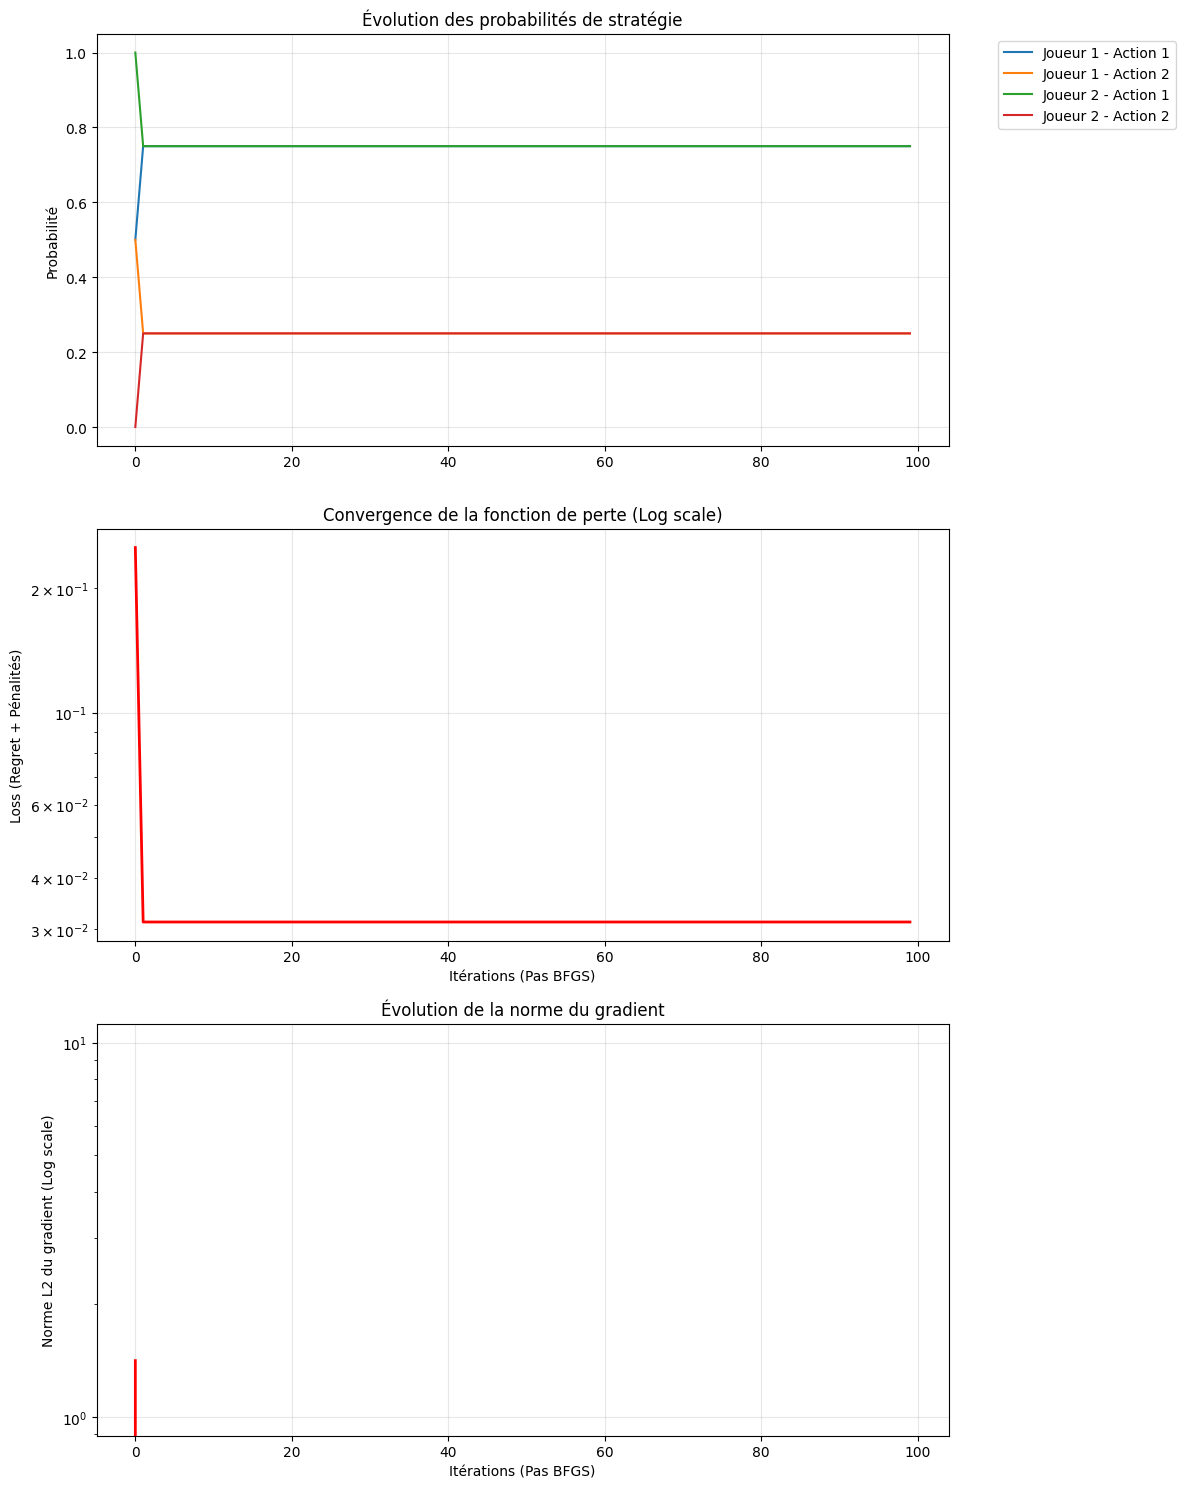


Distributions finales :
Joueur 0: [0.75 0.25]
Joueur 1: [0.75 0.25]


In [67]:
# Matrice de gain pour le Gardien (P0)
# Colonnes = Gardien (G, D) | Lignes = Tireur (G, D)
payoff_j1 = torch.tensor([[1,-1], 
                          [-1,1]], dtype=torch.float64)
# Jeu symétrique pour J2
payoff_j2 = torch.tensor([[1,-1], 
                          [-1,1]], dtype=torch.float64)

# Tenseur global [2 joueurs, 2 actions, 2 actions]
game_tenseur_cooperation = torch.stack([payoffs_p0, payoffs_p1])

strategies_initales = [[0.5,0.5],[1,0]]
# Création de l'instance pour le Penalty
game_cooperation = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=game_tenseur_cooperation,
    strategies_init=strategies_initales
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = game_cooperation.solve(iterations=100)

game_cooperation.plot_evolution()



C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  p=torch.tensor(p)
C:\Users\julie\AppData\Local\Temp\ipykernel_7832\1052246245.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q=torch.tensor(q)


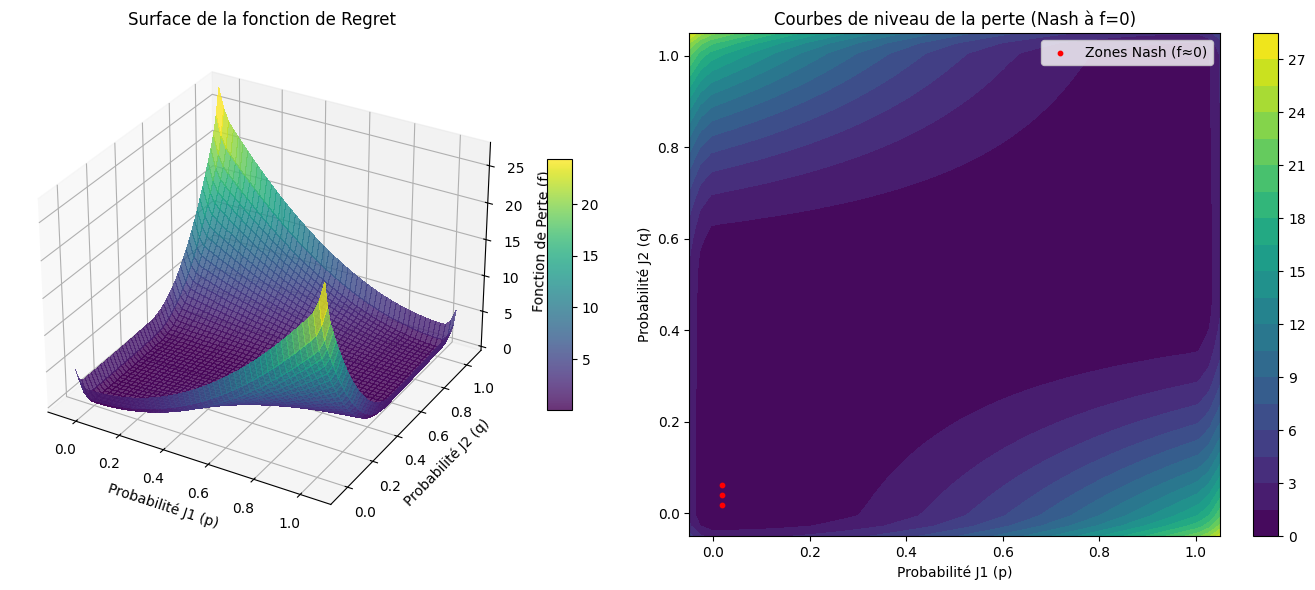

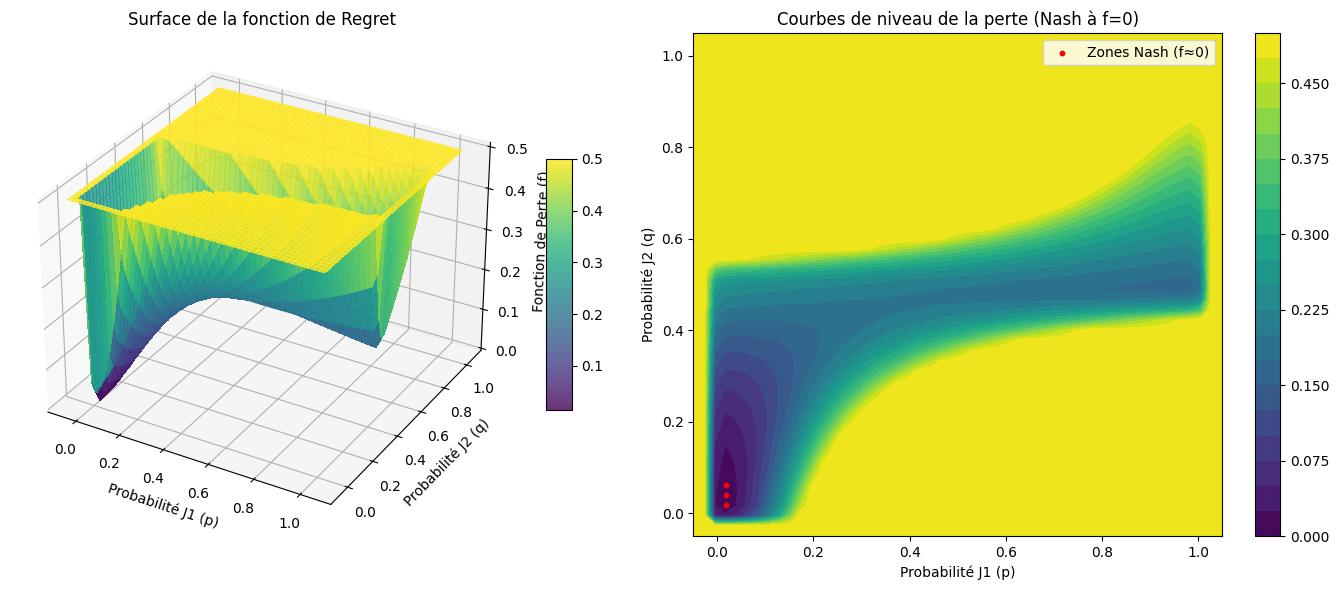

In [72]:

payoff_j1 = torch.tensor([[2,-2], 
                          [-2,2]], dtype=torch.float64)
# Jeu symétrique pour J2
payoff_j2 = torch.tensor([[-1.8,-1], 
                          [0,1]], dtype=torch.float64)

plot_regret(payoff_j1,payoff_j2)
plot_regret(payoff_j1,payoff_j2,plateau=0.5)

Le point associé aux stratégies suivantes est un minimum local non global (ce n'est pas un équilibre de Nash):
- Joueur 0: [ 1 0]
- Joueur 1: [0.495 0.505]

Ce point a aussi été trouvé théoriquement avec les valeurs des gains pour les actions pures.

Itération 0, Loss: 0.193600
Itération 10, Loss: 0.182811
Itération 20, Loss: 7.939636
Itération 30, Loss: 0.158466
Itération 40, Loss: 0.158419
Itération 50, Loss: 0.158415
Itération 60, Loss: 0.158415
Itération 70, Loss: 0.158415


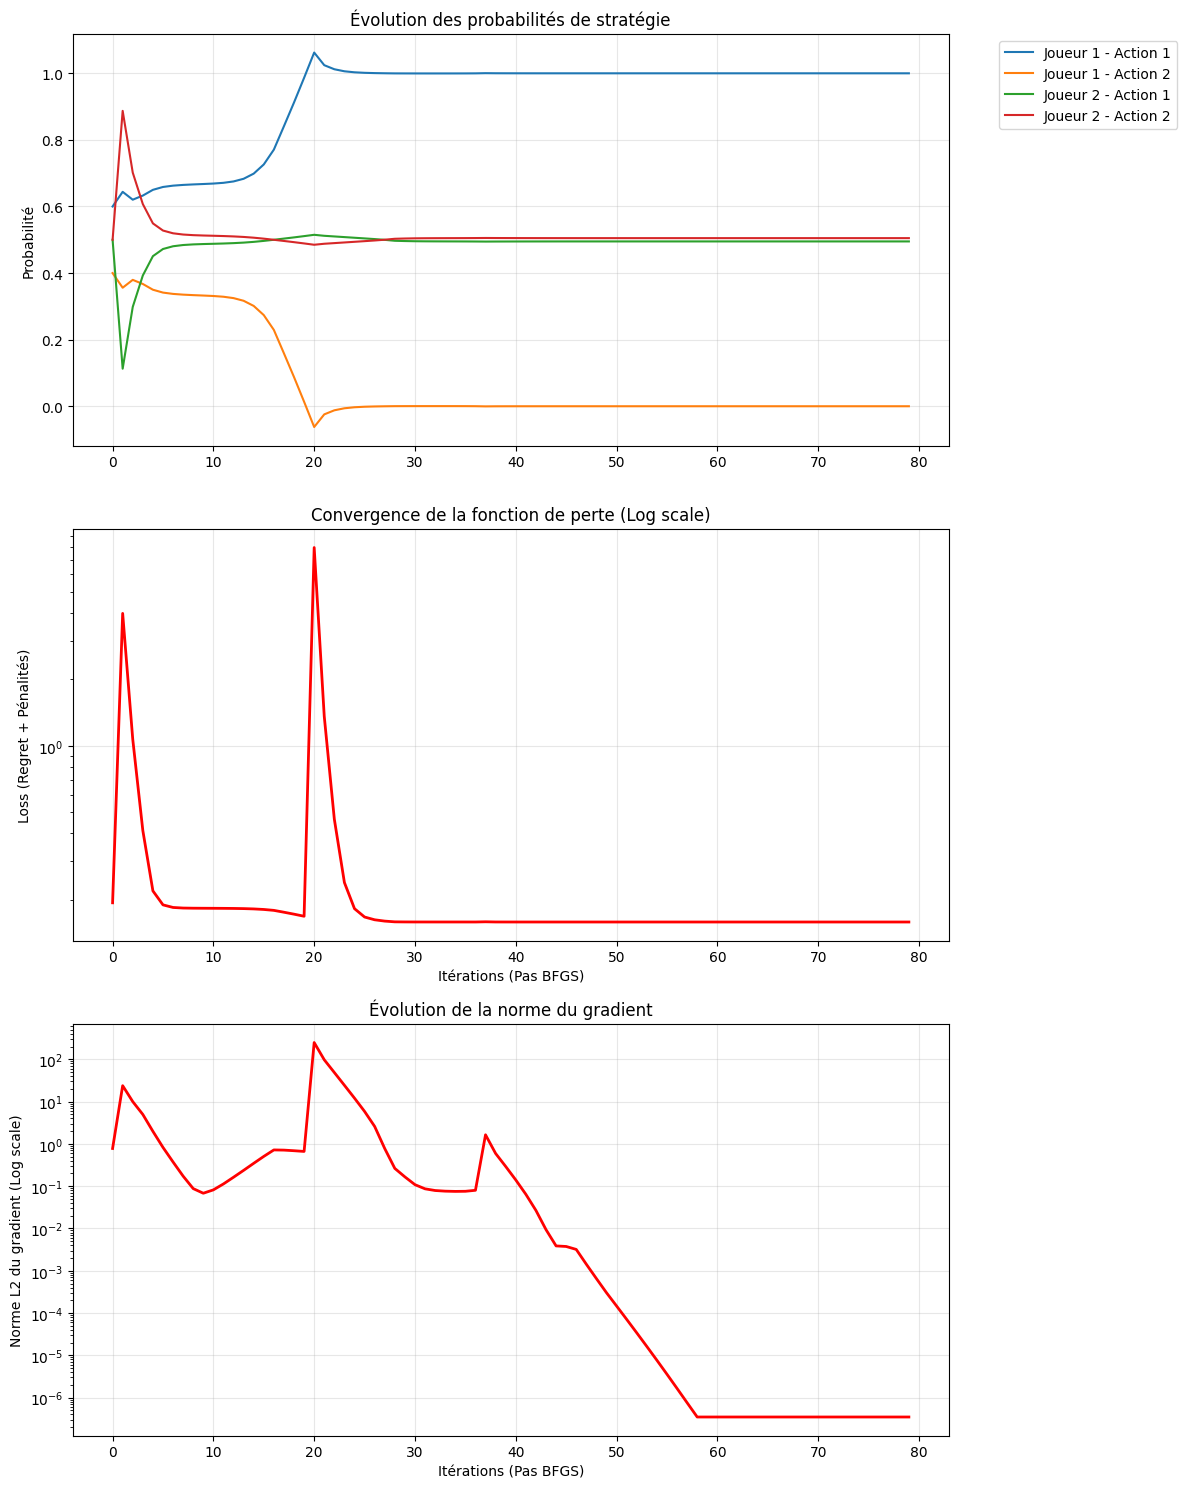


Distributions finales :
Joueur 0: [ 1. -0.]
Joueur 1: [0.495 0.505]


In [75]:

payoff_j1 = torch.tensor([[2,-2], 
                          [-2,2]], dtype=torch.float64)
# Jeu symétrique pour J2
payoff_j2 = torch.tensor([[-1.8,-1], 
                          [0,1]], dtype=torch.float64)

# Tenseur global [Nb_joueurs, Act_J1, Act_J2]
payoff_tensor = torch.stack([payoff_j1, payoff_j2])

strategies_initales = [[0.6,0.4],[0.5,0.5]]
# Création de l'instance pour le Penalty
game_limit = GameMinimizer(
    num_players=2, 
    num_actions=[2, 2], 
    payoff_tensor=payoff_tensor,
    strategies_init=strategies_initales
)

# Lancement de la résolution
# On surveille le gradient pour voir si L-BFGS "travaille" bien
final_strats = game_limit.solve(iterations=80)

game_limit.plot_evolution()
